# Build a self-correcting 3D collectible set with three.ws text-to-3D, function calling, and vision

Language models make excellent *art directors* and hopeless *sculptors*. A model
can imagine a coherent set of props for a scene, but it cannot produce geometry.
Function calling fixes that: give the model a text-to-3D tool and it can build
what it imagines.

But generative tools miss. Once in a while a prop comes back as a formless blob,
or the one feature that mattered is missing. So this notebook builds the whole
loop, not just the happy path. You hand an **AI art director** a one-line brief
("a wizard's study", "a windowsill of houseplants") and the model:

1. designs a matching set of individual props,
2. calls a real text-to-3D API once per prop **in parallel**,
3. **inspects a rendered image of every model it built**, grading each one
   against the brief with a structured verdict,
4. regenerates any prop that failed, using the critic's own revised prompt,

and the results render as an interactive 3D gallery **inside the notebook**:
orbit, zoom, and launch each model in AR.

Most function-calling examples return text or JSON. This one returns real,
downloadable 3D objects, and then turns the model's vision on its own output.
That generate, render, inspect, repair loop is the shape you need any time a
tool's output is generative and can silently miss: image generation, chart
rendering, UI screenshots, 3D.

![Pipeline architecture: a one-line brief goes to a gpt-5-mini art director, which issues parallel function calls to the keyless three.ws text-to-3D API; each GLB is rendered to a PNG and inspected by a vision critic returning a structured verdict; failed props are rebuilt once from the critic's revised prompt; passing props render in an interactive 3D gallery](../../images/threews_self_correcting_3d_pipeline.svg)

The committed run below turns the one-line brief "chunky potted houseplants
for a sunny windowsill" into this set. Three of the six props failed vision QA
and were each rebuilt once from the critic's own revised prompts; five of six
pass after the bounded repair:

![The finished houseplant set after vision QA: six potted plants generated from one brief; the three that failed QA (golden barrel cactus, monstera sapling, trailing pothos) were each rebuilt once from the critic's revised prompts](../../images/threews_houseplant_set_after_qa.png)

## What you'll learn

1. Wrap an external REST API as a **function tool** and describe it so the model
   produces clean arguments.
2. Run the **Responses API tool-calling loop**, handling **multiple parallel
   `function_call` items** in a single turn.
3. Close the loop with **vision QA**: render each tool result to an image and
   have the model grade its own work into a **strict structured-output schema**.
4. Run **bounded self-repair**: turn a failed grade into a better generation
   prompt, exactly once.
5. Turn raw tool output into a rich, interactive result (a live
   [`<model-viewer>`](https://modelviewer.dev/) gallery).

## The tools

The 3D tool is the free, keyless [three.ws](https://three.ws) text-to-3D
endpoint. It runs an open text-to-3D model (Microsoft
[TRELLIS](https://github.com/microsoft/TRELLIS) on NVIDIA NIM) and returns a
standard [glTF 2.0](https://www.khronos.org/gltf/) `.glb`. The QA step uses a
second keyless endpoint from the same API, which renders any GLB to a PNG.
Neither needs an account or API key, so both are free to run.

## Prerequisites

| You need | Used for | Notes |
|---|---|---|
| Python 3.10+ | running the notebook | the tool wrappers use PEP 604 union annotations (added in 3.10) |
| `OPENAI_API_KEY` | the art director's reasoning and vision QA | a full run costs a few cents with `gpt-5-mini` |
| `openai`, `requests`, `pillow` | API clients and PNG contact sheets | installed by the first cell |
| An HTML-rendering environment | the interactive 3D galleries (orbit, zoom, AR) | Jupyter, JupyterLab, VS Code, or Colab; static views like GitHub get a baked PNG contact sheet beneath each gallery |
| A three.ws account | nothing | both 3D endpoints are keyless and free; there is nothing to sign up for |

**The notebook ships fully executed, and live calls are opt-in.** Every result
below is real committed output from a live run, readable without executing
anything. The `RUN_LIVE` flag in the Setup cell (default `False`) gates every
cell that calls an external service, so a plain Run All makes no network calls
from the kernel beyond `pip` and replays the committed contact sheets in place of the live
galleries; flip the flag to `True` to reproduce the pipeline yourself. The
committed outputs throughout were produced by a full `RUN_LIVE = True`
execution against the live APIs. A live run takes roughly 10 to 15 minutes end to end, almost all of it 3D
generation time (about 30 to 90 seconds per prop, run in parallel).


## Setup

In [ ]:
%pip install --quiet --upgrade openai requests pillow

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import base64
import io
import os
import json
import time
from urllib.parse import quote
from concurrent.futures import ThreadPoolExecutor

import requests
from openai import OpenAI, OpenAIError
from IPython.display import HTML, Image, display

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", "<your OpenAI API key>"))

MODEL = "gpt-5-mini"            # any vision-capable, tool-calling model works
THREE_WS_BASE = "https://three.ws"
# -- Live-calls switch --------------------------------------------------------
# Running this notebook drives two live external services: the keyless three.ws
# text-to-3D and render endpoints (free, no account) and the OpenAI API (your
# OPENAI_API_KEY; a few cents with gpt-5-mini). The notebook ships fully
# executed, so every result is readable below without running anything. Flip to
# True to opt in and reproduce the whole pipeline yourself.
RUN_LIVE = False

SKIP_NOTE = ("RUN_LIVE is False: skipped the live calls and replayed this cell's "
             "committed results below. Set RUN_LIVE = True in the Setup cell to run it live.")


def show_committed(*receipts: str) -> None:
    """Replay the committed static contact sheets when a live cell is skipped,
    so a keyless Run All still ends with every result visible. Looks for the
    repo's images/ directory relative to common working directories; a
    standalone copy of the notebook falls back to a pointer at the hosted run.
    """
    from pathlib import Path

    print(SKIP_NOTE)
    for name in receipts:
        hit = next((p / name for p in
                    (Path("../../images"), Path("images"), Path("."))
                    if (p / name).is_file()), None)
        if hit:
            display(Image(filename=str(hit)))
        else:
            # Standalone copy (Colab, a downloaded .ipynb) without the repo's
            # images/ folder: emit an <img> pointing at the canonical copy.
            # The browser loads it; the kernel still makes no network call.
            display(Image(url="https://raw.githubusercontent.com/openai/"
                              f"openai-cookbook/main/images/{name}"))


## 1. A tool that makes real 3D

three.ws exposes a small, keyless endpoint that turns a prompt into a textured
`.glb`:

- **Submit:** `POST https://three.ws/api/3d/generate` with `{"prompt": "..."}`
- **Poll:** `GET https://three.ws/api/3d/generate?job=<id>` while `status` is `pending`

Generation usually finishes inside the first request and returns
`"status": "done"` directly; the poll loop only runs when the free lane is busy.
A finished response looks like this:

```json
{
  "status": "done",
  "glbUrl": "https://.../forge/anon/<id>.glb",
  "viewerUrl": "https://three.ws/viewer?src=...",
  "arUrl": "https://three.ws/api/ar?src=...",
  "tier": "draft",
  "free": true
}
```

The free lane is the *draft* tier: one subject, draft-fidelity geometry, no
rigging. It has a generous per-IP rate limit protecting a shared GPU allocation;
over the limit it returns `429` with a `Retry-After` header.

The wrapper below submits, polls if needed, retries transient failures, and
backs off for the lane's `Retry-After` when it hits the rate limit (capped at
two minutes, with a 15-second default when the header is absent), so a busy
moment slows a batch instead of failing it. When the lane finishes a job
inline, the submit call can legitimately hold for several minutes, so the
wrapper's read timeout outlasts the server's hold window. This is the real
function the model will call, no mocking.

In [ ]:
class GenerationError(RuntimeError):
    """Raised when a 3D generation terminally fails."""


def _retry_after_seconds(value: str | None, default: float = 15) -> float:
    """Parse a Retry-After header (delta-seconds or HTTP-date), clamped to [0, 120]."""
    try:
        seconds = float(value)
    except (TypeError, ValueError):
        from email.utils import parsedate_to_datetime
        try:
            from datetime import datetime, timezone
            seconds = (parsedate_to_datetime(value) - datetime.now(timezone.utc)).total_seconds()
        except (TypeError, ValueError):
            seconds = default
    return max(0.0, min(seconds, 120.0))


def generate_3d_model(prompt: str, name: str | None = None, timeout_s: int = 240) -> dict:
    """Turn a text prompt into a real 3D model (.glb) via the free three.ws lane.

    Returns a dict with ``status`` and, on success, ``glbUrl`` / ``viewerUrl`` /
    ``arUrl``. ``name`` is an optional short label carried through for the
    gallery. Raises ``GenerationError`` if the lane reports a terminal failure.
    """
    prompt = prompt.strip()[:1000]  # the lane rejects prompts over its 1000-char ceiling
    transient_status = {502, 503, 504}

    def _submit_and_poll() -> dict:
        # The lane holds the submit open and usually completes inline, so the
        # read timeout must outlast the server's hold window (up to ~4 min);
        # aborting early would orphan the job and duplicate work on a retry.
        resp = requests.post(
            f"{THREE_WS_BASE}/api/3d/generate",
            json={"prompt": prompt},
            timeout=(10, 300),
        )
        resp.raise_for_status()
        data = resp.json()

        job = data.get("job")
        if data.get("status") == "pending" and not job:
            raise GenerationError("pending response carried no job token")

        deadline = time.time() + timeout_s
        while data.get("status") == "pending" and time.time() < deadline:
            # Every pending response carries a retryAfter poll-cadence hint in
            # seconds; honoring it is what keeps the poll from tripping the
            # lane's rate limit in the first place.
            time.sleep(min(max(float(data.get("retryAfter") or 3), 1), 30))
            try:
                # `title` labels the finished viewer/AR pages with the prompt.
                poll = requests.get(
                    f"{THREE_WS_BASE}/api/3d/generate",
                    params={"job": job, "title": prompt},
                    timeout=(10, 60),
                )
            except (requests.Timeout, requests.ConnectionError):
                # A network blip on the poll leg must not abandon the job:
                # resubmitting would duplicate the generation. Keep polling.
                continue
            if poll.status_code == 429:
                # Rate-limited mid-poll: wait out Retry-After on the SAME job.
                time.sleep(_retry_after_seconds(poll.headers.get("retry-after")))
                continue
            if poll.status_code in transient_status:
                continue  # edge hiccup mid-poll; same job, next cadence tick
            poll.raise_for_status()
            data = poll.json()
        return data

    # The retry loop below only re-submits when the SUBMIT itself failed:
    # network errors before a job existed, brief lane saturation (502/503/504),
    # or the per-IP rate limit (429, honoring Retry-After). Failures on the
    # poll leg are absorbed above so an in-flight job is never duplicated.
    # A bad prompt (other 4xx) is not retried.
    last_exc = None
    for attempt in range(3):
        try:
            data = _submit_and_poll()
            break
        except (requests.Timeout, requests.ConnectionError) as exc:
            last_exc = exc
        except requests.HTTPError as exc:
            status = exc.response.status_code if exc.response is not None else None
            if status == 429:
                last_exc = exc
                time.sleep(_retry_after_seconds(exc.response.headers.get("retry-after")))
                continue
            if status not in transient_status:
                raise
            last_exc = exc
        time.sleep(3)
    else:
        raise last_exc

    if data.get("status") != "done" or not data.get("glbUrl"):
        raise GenerationError(data.get("error", f"generation did not complete: {data.get('status')}"))
    return {"name": name or prompt, "prompt": prompt, **data}


## 2. A gallery to show it off

A `.glb` is not much fun as a URL in a print statement. The helper below renders
any list of generations as an interactive grid using
[`<model-viewer>`](https://modelviewer.dev/), the open web component for glTF.
Each card orbits on its own and links out to the full viewer and to AR.

Hand it the dicts `generate_3d_model` returns and it renders the grid inline.
It also handles the empty case, so it is safe to call even if every generation
in a batch failed.

One catch: `<model-viewer>` needs a live `<script>` tag, and static notebook
views (GitHub, the cookbook site) strip scripts. So the helper also fetches one
static server-side render per model, from a second keyless endpoint on the same
API that we will meet properly in the QA section, and stitches them into a
plain PNG contact sheet below the gallery. Live sessions get the interactive
grid; static views still see the models.

In [ ]:
_MV = "https://unpkg.com/@google/model-viewer@^3.5.0/dist/model-viewer.min.js"
_CSS = """
.twg{--panel:#141821;--line:#232838;--txt:#e7e9f0;--muted:#8b93a7;--accent:#8b7bf7;
  background:radial-gradient(1100px 380px at 18% -20%,#1a1f2e 0%,#0b0d12 62%);
  border:1px solid var(--line);border-radius:18px;padding:22px 22px 26px;color:var(--txt);
  font-family:ui-sans-serif,-apple-system,"Segoe UI",Roboto,sans-serif;}
.twg *{box-sizing:border-box;}
.twg .eyebrow{font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-size:11px;
  letter-spacing:.14em;text-transform:uppercase;color:var(--accent);}
.twg h3{margin:.4em 0 .12em;font-size:22px;font-weight:650;letter-spacing:-.01em;}
.twg .sub{margin:0;color:var(--muted);font-size:13.5px;max-width:64ch;line-height:1.5;}
.twg .head{margin-bottom:18px;}
.twg .grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(210px,1fr));gap:16px;}
.twg .empty{color:var(--muted);font-size:14px;padding:26px 4px;}
.twg figure{margin:0;background:var(--panel);border:1px solid var(--line);border-radius:14px;
  overflow:hidden;transition:transform .18s ease,box-shadow .18s ease,border-color .18s ease;}
.twg figure:hover{transform:translateY(-4px);box-shadow:0 14px 32px -14px rgba(0,0,0,.75);
  border-color:#374060;}
.twg model-viewer{width:100%;height:200px;
  background:radial-gradient(140px 140px at 50% 32%,#1c2233,#0e1119);--poster-color:transparent;}
.twg figcaption{display:flex;align-items:center;justify-content:space-between;
  padding:11px 13px;border-top:1px solid var(--line);gap:10px;}
.twg .name{font-size:14px;font-weight:600;white-space:nowrap;overflow:hidden;text-overflow:ellipsis;}
.twg .links{display:flex;gap:8px;flex:none;}
.twg .links a{font-size:11px;color:var(--muted);text-decoration:none;border:1px solid var(--line);
  padding:3px 9px;border-radius:999px;transition:.15s;}
.twg .links a:hover{color:var(--txt);border-color:var(--accent);}
"""

def _static_png(glb_url: str, size: int = 280) -> bytes:
    """One static server-side render of a GLB, as PNG bytes (keyless)."""
    resp = requests.get(
        f"{THREE_WS_BASE}/api/render/glb",
        params={"glbUrl": glb_url, "width": size, "height": size},
        timeout=(10, 90),
    )
    resp.raise_for_status()
    return resp.content


def _stitch(tiles, tile: int, per_row: int = 4, pad: int = 10) -> bytes:
    """Lay PIL tiles onto a dark grid and return the sheet as PNG bytes."""
    from PIL import Image as PILImage

    rows = [tiles[i : i + per_row] for i in range(0, len(tiles), per_row)]
    width = pad + max(len(r) for r in rows) * (tile + pad)
    height = pad + len(rows) * (tile + pad)
    sheet = PILImage.new("RGB", (width, height), "#0b0d12")
    for r, row in enumerate(rows):
        for c, t in enumerate(row):
            sheet.paste(t, (pad + c * (tile + pad), pad + r * (tile + pad)))
    buf = io.BytesIO()
    sheet.save(buf, format="PNG")
    return buf.getvalue()


def contact_sheet(items, tile: int = 280) -> bytes | None:
    """Stitch one static render per model into a single PNG contact sheet.

    Tiles fetch in parallel; a tile whose render fails is skipped rather than
    sinking the whole sheet. Returns None when nothing rendered.
    """
    from PIL import Image as PILImage

    def fetch(it):
        try:
            return _static_png(it["glbUrl"], tile)
        except Exception:
            return None

    with ThreadPoolExecutor(max_workers=4) as pool:
        raw = list(pool.map(fetch, items))
    tiles = [PILImage.open(io.BytesIO(b)) for b in raw if b]
    if not tiles:
        return None
    return _stitch(tiles, tile)


def render_models(items, title="Collection", subtitle=None):
    """Show a set of generations twice: the interactive gallery for live
    sessions, then a static contact sheet that survives script-free views."""
    import html
    if not items:
        body = '<p class="empty">No models to show yet. Generate some first.</p>'
    else:
        cards = []
        for it in items:
            name = html.escape(str(it.get("name") or it.get("prompt") or "Model"))
            # model-viewer fetches the GLB from the browser, and the object
            # store only answers CORS for allowlisted origins. The keyless
            # /api/glb proxy answers for ANY origin (Jupyter, Colab, this
            # notebook rendered on a website), so the gallery works everywhere.
            proxied = f"{THREE_WS_BASE}/api/glb?src={quote(it['glbUrl'], safe='')}"
            glb = html.escape(proxied, quote=True)
            viewer = html.escape(it.get("viewerUrl") or "", quote=True)
            ar = html.escape(it.get("arUrl") or "", quote=True)
            cards.append(f'''    <figure>
      <model-viewer src="{glb}" alt="{name}" camera-controls auto-rotate
          auto-rotate-delay="0" rotation-per-second="20deg" shadow-intensity="1"
          exposure="1.05" environment-image="neutral" interaction-prompt="none"></model-viewer>
      <figcaption>
        <span class="name">{name}</span>
        <span class="links"><a href="{viewer}" target="_blank" rel="noopener">open</a><a href="{ar}" target="_blank" rel="noopener">AR</a></span>
      </figcaption>
    </figure>''')
        body = '<div class="grid">\n' + chr(10).join(cards) + '\n    </div>'
    sub = f'<p class="sub">{html.escape(subtitle)}</p>' if subtitle else ""
    display(HTML(f'''<div class="twg">
  <style>{_CSS}</style>
  <script type="module" src="{_MV}"></script>
  <div class="head">
    <span class="eyebrow">// three.ws &times; function calling</span>
    <h3>{html.escape(title)}</h3>{sub}
  </div>
{body}
</div>'''))
    if items:
        png = contact_sheet(items)
        if png:
            display(Image(data=png))

## 3. The payoff, by hand

Before we bring in the model, let's run the pipeline manually to confirm the
parts work: pick a themed set of props, generate them **in parallel**, and
render the gallery. `safe_generate` isolates each prop so one failure never sinks
the batch. Every model below was generated live by this cell.

generated 4/4 props


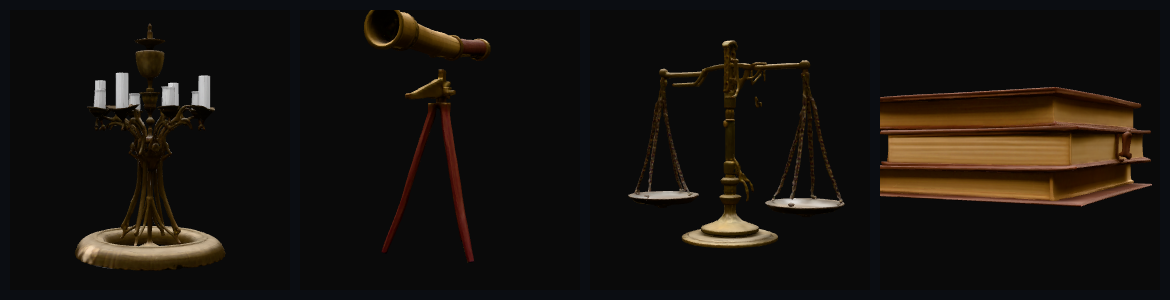

In [ ]:
PROPS = [
    ("Candelabra", "a tarnished bronze candelabra with three twisted arms and melted white candles"),
    ("Telescope",  "a brass spyglass telescope on a mahogany tripod"),
    ("Scale",      "an antique brass balance scale with two chained pans"),
    ("Book stack", "a stack of three old leather books with gilded spines"),
]

def safe_generate(name, prompt):
    try:
        return generate_3d_model(prompt, name=name)
    except (GenerationError, requests.RequestException) as err:
        print(f"  skipped {name}: {err}")
        return None

if RUN_LIVE:
    with ThreadPoolExecutor(max_workers=4) as pool:
        study = [m for m in pool.map(lambda p: safe_generate(*p), PROPS) if m]

    print(f"generated {len(study)}/{len(PROPS)} props")
    render_models(
        study,
        title="A wizard's study",
        subtitle="Four props, one sentence each, generated on the free three.ws draft "
                 "lane and rendered inline. Drag to orbit; tap AR on a phone.",
    )
else:
    show_committed("threews_wizard_study_set.png")


## 4. Let the model art-direct

Now we hand the wheel to the model. We describe `generate_3d_model` as a function
tool, give the model a brief, and let it decide *which* props make a coherent set
and call the tool for each one. The prompt-writing we did by hand becomes the
model's job.

The tool takes two fields: a short `name` for the gallery label and a `prompt`
that must be a single, clear subject (the draft lane models one subject best).

In [ ]:
tools = [
    {
        "type": "function",
        "name": "generate_3d_model",
        "description": (
            "Generate one real, downloadable 3D model (.glb) from a short "
            "description of a SINGLE subject. Call once per prop."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "name": {
                    "type": "string",
                    "description": "Short display label, e.g. 'Lantern'.",
                },
                "prompt": {
                    "type": "string",
                    "description": (
                        "One single subject to model, with concrete visual "
                        "detail (material, style, color). No scenes, no lists."
                    ),
                },
            },
            "required": ["name", "prompt"],
            "additionalProperties": False,
        },
    }
]

### How the loop works

The loop is the standard Responses API tool-calling pattern, with one upgrade:
the model emits **several** `function_call` items in a single turn (one per
prop), so we run them concurrently.

1. Send the conversation plus the tool definitions.
2. Append the model's entire `output` to the conversation. Reasoning models
   pair each `function_call` with a `reasoning` item, and the API rejects a
   follow-up turn that has one without the other, so append everything rather
   than cherry-picking the calls.
3. For every `function_call` the model returned this turn, run the real
   function (all of them in parallel) and append a `function_call_output` for
   each.
4. Send the updated conversation back so the model can react, call more tools,
   or write its final summary.
5. Repeat until the model stops calling tools.

Each tool call is wrapped so that a single failed generation reports its error
back to the model instead of crashing the run.

In [ ]:
ART_DIRECTOR = (
    "You are a 3D art director. When the user gives a theme, design a small, "
    "coherent set of 4-6 individual props that would furnish that scene, and "
    "call generate_3d_model once per prop. Each prompt must be a single clear "
    "subject. When every prop is generated, briefly describe the set you made."
)


def run_art_director(brief: str, model: str = MODEL, max_rounds: int = 4) -> dict:
    conversation = [
        {"role": "system", "content": ART_DIRECTOR},
        {"role": "user", "content": brief},
    ]
    gallery = []

    for _ in range(max_rounds):
        response = client.responses.create(
            model=model,
            input=conversation,
            tools=tools,
            parallel_tool_calls=True,
        )
        calls = [item for item in response.output if item.type == "function_call"]
        if not calls:
            return {"reply": response.output_text, "items": gallery}

        def run_call(call):
            args = json.loads(call.arguments)
            try:
                result = generate_3d_model(**args)
                payload = {"status": "done", "glbUrl": result["glbUrl"]}
            except (GenerationError, requests.RequestException) as err:
                result, payload = None, {"status": "error", "error": str(err)}
            return call, args, result, payload

        # Feed the model's ENTIRE output back first. Reasoning models emit
        # reasoning items paired with their function calls, and the API
        # rejects a follow-up turn that carries a function_call without its
        # reasoning item, so append response.output wholesale rather than
        # cherry-picking the calls.
        conversation.extend(response.output)

        # Run every tool call from this turn concurrently.
        with ThreadPoolExecutor(max_workers=4) as pool:
            for call, args, result, payload in pool.map(run_call, calls):
                flag = "built" if result else "failed"
                print(f"  {flag:<6} {args['name']:<16} <- {args['prompt']}")
                if result:
                    gallery.append(result)
                conversation.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(payload),
                })

    return {"reply": "(stopped after max rounds)", "items": gallery}

Give it a brief and watch it work. The model invents the prop list, writes a
clean prompt for each, and the tool turns every one into real geometry. Try your
own brief by editing `WINDOWSILL_BRIEF` at the top of the next cell (keep
`THEME` matching):

  built  Echeveria (Teal Pot) <- A single chunky stylized Echeveria succulent: a tight rosette of plump, rounded leaves with a mint-to-emerald gradient and soft hand-painted highlights. Plant sits in a squat, slightly chipped teal glazed ceramic pot with a visible rim, coarse potting soil, and a tiny drainage hole. Visual style: collectible/toy-like with exaggerated, chunky proportions, smooth normals, clean silhouette, warm sunlit palette and subtle surface wear. Texturing: PBR with hand-painted details. Optimization: real-time friendly, approx. 3k–6k tris; centered on origin and placed on a subtle ground plane with a soft cast shadow. Single subject, no additional props.
  built  Golden Barrel Cactus (Concrete Pot) <- A single chunky golden barrel cactus (Echinocactus) with rounded vertical ribs and oversized soft yellow spines (non-pointy, toy-friendly), deep emerald body with light variegation. Planted in a low, ribbed light-gray concrete pot with a rough texture and a small matchi

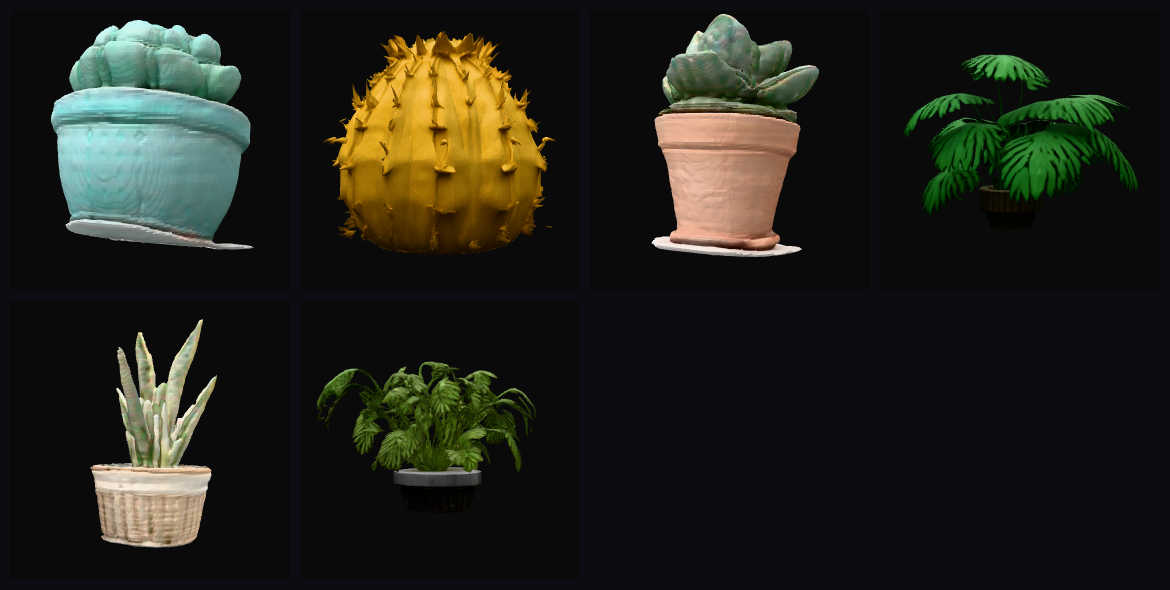

In [ ]:
WINDOWSILL_BRIEF = (
    "Design a collectible set of chunky potted houseplants for a sunny "
    "windowsill: succulents, cacti, and broad-leaf plants in characterful pots."
)
THEME = "A windowsill of houseplants"   # gallery headline; keep it matching the brief

if RUN_LIVE:
    collection = run_art_director(WINDOWSILL_BRIEF)

    print("\nArt director:", collection["reply"])
    render_models(
        collection["items"],
        title=THEME,
        subtitle="Designed and built by the model from a single-line brief.",
    )
else:
    show_committed("threews_houseplant_set.png")


## 5. The model inspects its own work

So far the loop trusts every generation. But text-to-3D is a lossy, generative
process: once in a while the geometry comes back as a vague blob, or the key
feature the prompt asked for simply is not there. Most pipelines ship whatever
came back, because nothing in them can see.

Our model can. three.ws exposes the same headless renderer it uses for its own
share cards: `GET /api/render/glb?glbUrl=...` returns a PNG of any GLB, no key
required. That closes the loop: render each generated model to an image, show
that image back to the model together with the brief and the original prompt,
and ask for a verdict.

Two implementation choices here are worth copying into any pipeline:

- **Structured output, not prose.** The critique uses a strict JSON schema, so
  `passed` is a real boolean you can branch on, and `revised_prompt` is directly
  machine-usable rather than advice buried in a paragraph.
- **QA fails open.** If the renderer is unavailable, the prop keeps its draft
  and the verdict records that the check was skipped. A guardrail that can take
  down the pipeline it guards is worse than no guardrail.
- **The critic is calibrated to the tier.** A draft lane judged against
  production standards fails everything, and an over-eager critic writes
  1,000-character "revised prompts" that a single-subject generator cannot use.
  The system prompt tells the critic what normal looks like at this tier, to
  fail only on identity (could a stranger name the subject?), and to keep any
  rewrite short and concrete.

This is the same shape as a model-graded eval, run inline: the critic grades
output against intent, and the grade is data.

In [ ]:
def snapshot(glb_url: str, size: int = 512) -> str:
    """Render a GLB to a PNG via the keyless three.ws renderer; returns base64.

    Retries once: the renderer cold-starts a headless browser, so the first
    hit under parallel load can time out upstream and return a 5xx.
    """
    last_err = None
    for attempt in range(2):
        try:
            resp = requests.get(
                f"{THREE_WS_BASE}/api/render/glb",
                params={"glbUrl": glb_url, "width": size, "height": size},
                timeout=(10, 60),
            )
            resp.raise_for_status()
            ctype = resp.headers.get("content-type", "")
            if not ctype.startswith("image/"):
                raise RuntimeError(f"renderer returned {ctype or 'no content type'}")
            return base64.b64encode(resp.content).decode()
        except (requests.RequestException, RuntimeError) as err:
            last_err = err
            time.sleep(4)
    raise last_err


CRITIC = (
    "You are the art QA reviewer for a draft-tier text-to-3D pipeline. You "
    "are shown one render of a generated 3D model, plus the set's theme and "
    "the prompt that produced it. Draft tier means soft edges, modest "
    "textures, simple silhouettes, and missing fine detail are all normal, "
    "and all pass. Fail a model only when a stranger could not name the "
    "subject from the render (wrong subject, or geometry collapsed into a "
    "blob), or when the look clearly fights the theme. When a model fails, "
    "write a revised generation prompt: one single subject, under 400 "
    "characters, plain concrete words for shape, material, and color. Never "
    "write a spec sheet; the generator conditions on one short description."
)

CRITIQUE_SCHEMA = {
    "type": "object",
    "properties": {
        "passed": {
            "type": "boolean",
            "description": "true if the model is a usable draft of the requested prop",
        },
        "critique": {
            "type": "string",
            "description": "One or two sentences: what the render shows and why it passes or fails.",
        },
        "revised_prompt": {
            "type": ["string", "null"],
            "description": (
                "Only when passed is false: an improved single-subject generation "
                "prompt that fixes the defect. Otherwise null."
            ),
        },
    },
    "required": ["passed", "critique", "revised_prompt"],
    "additionalProperties": False,
}


def _grade(item: dict, theme: str, image_b64: str) -> dict:
    """One vision call: show the critic the render and get a structured verdict."""
    response = client.responses.create(
        model=MODEL,
        input=[
            {"role": "system", "content": CRITIC},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": (
                            f"Theme: {theme}\n"
                            f"Prop: {item['name']}\n"
                            f"Generation prompt: {item['prompt']}"
                        ),
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/png;base64,{image_b64}",
                    },
                ],
            },
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "critique",
                "strict": True,
                "schema": CRITIQUE_SCHEMA,
            }
        },
    )
    return {**item, "snapshot": image_b64, "verdict": json.loads(response.output_text)}


def inspect_model(item: dict, theme: str) -> dict:
    """Attach a vision verdict to one generation. Fails open if QA itself fails."""
    try:
        image_b64 = snapshot(item["glbUrl"])
    except (requests.RequestException, RuntimeError) as err:
        print(f"  QA skipped for {item['name']}: {err}")
        skipped = {"passed": True, "critique": "QA skipped: renderer unavailable.",
                   "revised_prompt": None}
        return {**item, "verdict": skipped}
    try:
        return _grade(item, theme, image_b64)
    except (OpenAIError, ValueError) as err:
        # The same fail-open stance as the renderer: a transient API error or
        # an unparseable verdict must not take down the pipeline it guards.
        print(f"  QA skipped for {item['name']}: {err}")
        skipped = {"passed": True, "critique": "QA skipped: critic unavailable.",
                   "revised_prompt": None}
        return {**item, "snapshot": image_b64, "verdict": skipped}

The helper below shows a QA pass the honest way: each card pairs the render
the critic inspected (downscaled for the card grid) with the verdict it
produced. Like the galleries, the helper also emits the pass as one plain PNG
built from the full-resolution renders, with a green (pass) or red (retry) bar
over each tile, so the QA receipts survive script-free views too. Run it on
the houseplant set:



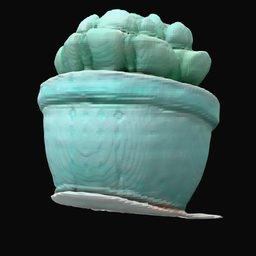
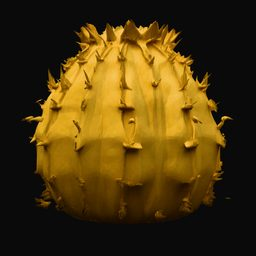
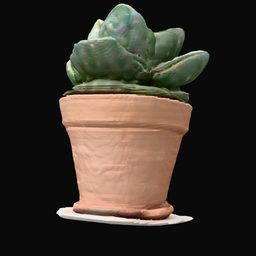
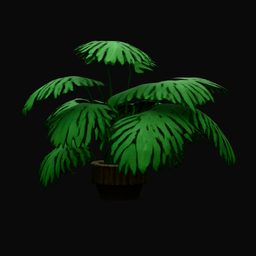
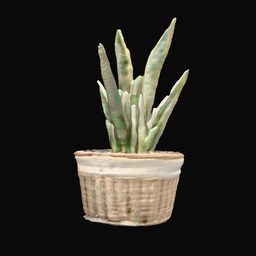
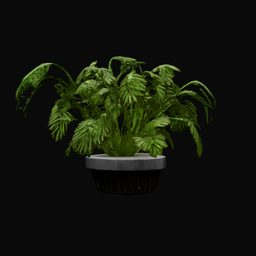

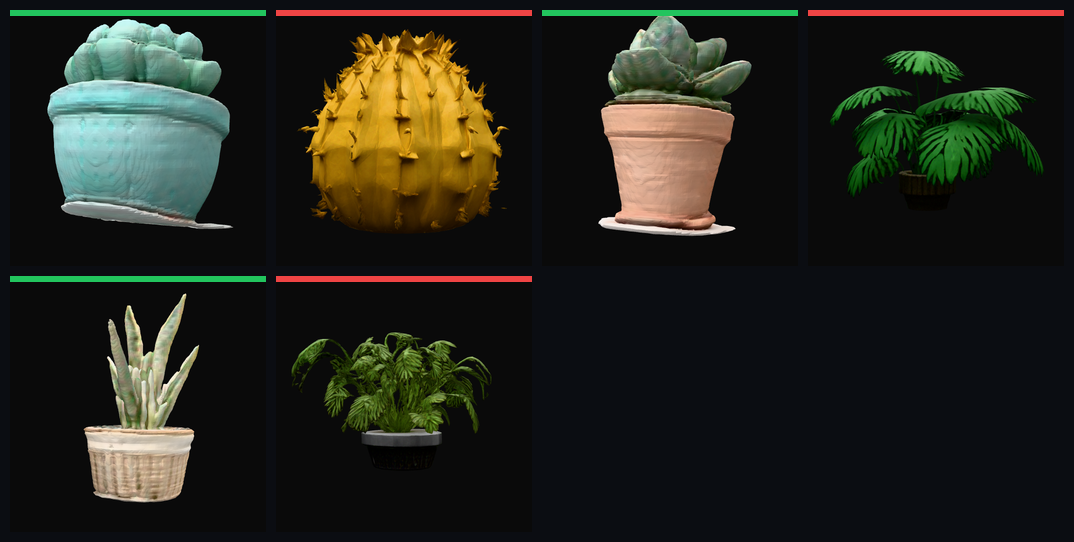

In [ ]:
_QA_CSS = """
.twq{--panel:#141821;--line:#232838;--txt:#e7e9f0;--muted:#8b93a7;--accent:#8b7bf7;
  background:radial-gradient(1100px 380px at 18% -20%,#1a1f2e 0%,#0b0d12 62%);
  border:1px solid var(--line);border-radius:18px;padding:22px 22px 26px;color:var(--txt);
  font-family:ui-sans-serif,-apple-system,"Segoe UI",Roboto,sans-serif;}
.twq *{box-sizing:border-box;}
.twq .eyebrow{font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-size:11px;
  letter-spacing:.14em;text-transform:uppercase;color:var(--accent);}
.twq h3{margin:.4em 0 .12em;font-size:22px;font-weight:650;letter-spacing:-.01em;}
.twq .sub{margin:0 0 18px;color:var(--muted);font-size:13.5px;max-width:64ch;line-height:1.5;}
.twq .grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(200px,1fr));gap:16px;}
.twq figure{margin:0;background:var(--panel);border:1px solid var(--line);border-radius:14px;
  overflow:hidden;}
.twq img{display:block;width:100%;aspect-ratio:1;object-fit:cover;
  background:radial-gradient(140px 140px at 50% 32%,#1c2233,#0e1119);}
.twq .noimg{display:flex;align-items:center;justify-content:center;aspect-ratio:1;
  color:var(--muted);font-size:12px;}
.twq figcaption{padding:11px 13px;border-top:1px solid var(--line);}
.twq .row{display:flex;align-items:center;justify-content:space-between;gap:10px;}
.twq .name{font-size:14px;font-weight:600;white-space:nowrap;overflow:hidden;text-overflow:ellipsis;}
.twq .badge{flex:none;font-family:ui-monospace,Menlo,monospace;font-size:10.5px;
  letter-spacing:.08em;text-transform:uppercase;padding:3px 9px;border-radius:999px;
  border:1px solid var(--line);}
.twq .badge.ok{color:#4ade80;border-color:#295b40;}
.twq .badge.bad{color:#f87171;border-color:#5e3030;}
.twq .crit{margin:7px 0 0;font-size:12px;line-height:1.45;color:var(--muted);}
"""


def _thumb(b64_png: str, size: int = 256) -> str:
    """Downscale a snapshot to a compact JPEG data URI for the card grid; the
    composite sheet below keeps the full-resolution renders."""
    from PIL import Image as PILImage
    img = PILImage.open(io.BytesIO(base64.b64decode(b64_png))).convert("RGB")
    img.thumbnail((size, size), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, "JPEG", quality=82)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()


def verdict_sheet(items, tile: int = 256, bar: int = 6) -> bytes | None:
    """The QA pass as one plain PNG: each tile is the exact render the critic
    saw, with a green (pass) or red (retry) bar across the top."""
    from PIL import Image as PILImage

    tiles = []
    for it in items:
        if not it.get("snapshot"):
            continue
        img = PILImage.open(io.BytesIO(base64.b64decode(it["snapshot"])))
        img = img.convert("RGB").resize((tile, tile), PILImage.LANCZOS)
        ok = bool((it.get("verdict") or {}).get("passed"))
        img.paste(PILImage.new("RGB", (tile, bar), "#22c55e" if ok else "#ef4444"), (0, 0))
        tiles.append(img)
    if not tiles:
        return None
    return _stitch(tiles, tile)


def render_verdicts(items, title="QA pass", subtitle=None):
    """Show inspected generations as snapshot + verdict cards, plus the same
    pass as a single static PNG."""
    import html
    cards = []
    for it in items:
        verdict = it.get("verdict") or {}
        ok = bool(verdict.get("passed"))
        name = html.escape(str(it.get("name") or "Model"))
        critique = html.escape(verdict.get("critique") or "")
        if it.get("snapshot"):
            img = f'<img src="{_thumb(it["snapshot"])}" alt="render of {name}">'
        else:
            img = '<div class="noimg">no render</div>'
        badge = ("ok", "pass") if ok else ("bad", "retry")
        cards.append(f'''    <figure>
      {img}
      <figcaption>
        <div class="row"><span class="name">{name}</span><span class="badge {badge[0]}">{badge[1]}</span></div>
        <p class="crit">{critique}</p>
      </figcaption>
    </figure>''')
    sub = f'<p class="sub">{html.escape(subtitle)}</p>' if subtitle else ""
    display(HTML(f'''<div class="twq">
  <style>{_QA_CSS}</style>
  <span class="eyebrow">// vision QA</span>
  <h3>{html.escape(title)}</h3>{sub}
  <div class="grid">
{chr(10).join(cards)}
  </div>
</div>'''))
    png = verdict_sheet(items)
    if png:
        display(Image(data=png))


if RUN_LIVE:
    if "collection" not in globals():
        raise RuntimeError("Run the art-director cell above with RUN_LIVE = True first.")
    with ThreadPoolExecutor(max_workers=4) as pool:
        inspected = list(pool.map(lambda item: inspect_model(item, WINDOWSILL_BRIEF),
                                  collection["items"]))

    render_verdicts(
        inspected,
        title="What the critic saw",
        subtitle="Each card is the exact image the model inspected, with its structured verdict.",
    )
else:
    show_committed("threews_houseplant_qa_verdicts.png")


## 6. The repair loop

A failed verdict is not a dead end, because the critic already wrote the fix.
`repair` takes an inspected set, regenerates every failed prop from its
`revised_prompt`, and re-inspects the result.

One rule keeps this honest: **the loop gets a budget of exactly one retry per
prop.** A self-correcting loop without a hard budget will happily spend forever
(and real money) fighting a defect the underlying generator cannot fix. One
retry captures most of the win; after that, ship the draft or flag it for a
human.

  rebuilding Golden Barrel Cactus (Concrete Pot) <- Chunky golden barrel cactus with rounded vertical ribs, deep emerald body with light variegation and oversized soft pale‑yellow spines, planted in a low ribbed light‑gray concrete pot with a small matching drainage saucer and coarse pebble topdressing; stylized collectible, warm sunlit shading.
  rebuilding Monstera Sapling (Mustard Enamel Pot) <- Small chunky Monstera deliciosa sapling with exactly three broad glossy leaves, each leaf showing simple soft fenestrations and thick petioles; planted in a vintage mustard-yellow enamel pot with a thin dark rim and hand-painted white dot motif, slight enamel chips and visible topsoil, toy-like hand-painted finish, warm window-lit tones.
  rebuilding Trailing Pothos (Half-Moon Planter) <- Trailing pothos with several chunky heart-shaped glossy leaves, mid-green with yellow-gold variegation; vines naturally cascading over the rim. Planted in a flat half‑moon ceramic planter with a soft pastel

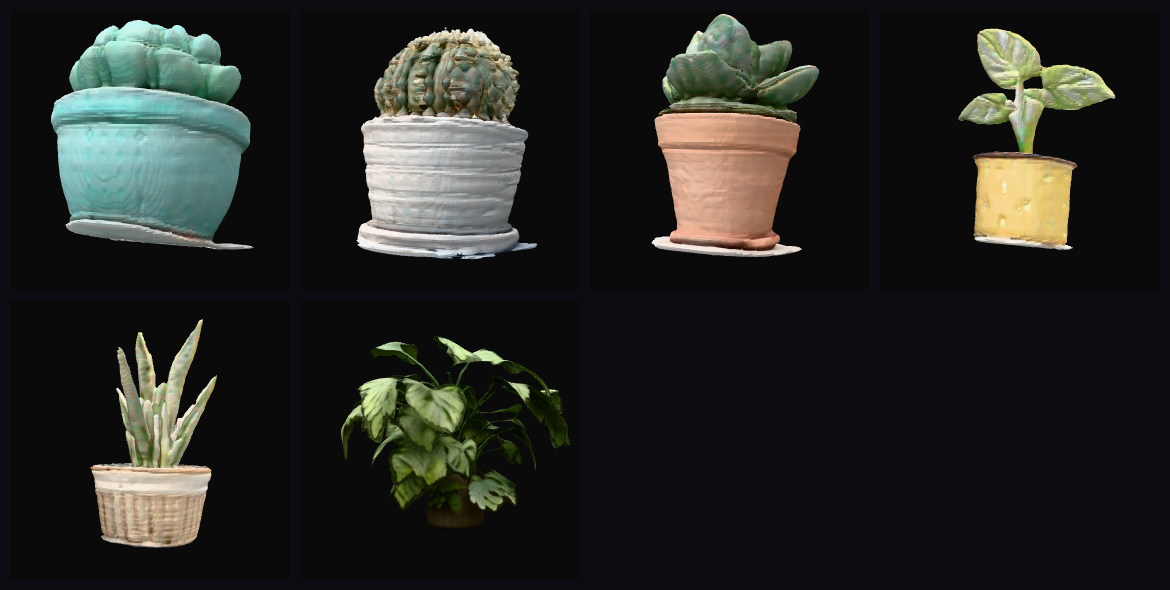

In [ ]:
def repair(inspected: list, theme: str) -> list:
    """Regenerate each failed prop once, from the critic's own revised prompt."""
    def fix(item):
        verdict = item["verdict"]
        if verdict["passed"] or not verdict["revised_prompt"]:
            return item
        print(f"  rebuilding {item['name']} <- {verdict['revised_prompt']}")
        try:
            redo = generate_3d_model(verdict["revised_prompt"], name=item["name"])
        except (GenerationError, requests.RequestException) as err:
            print(f"  rebuild failed for {item['name']}, keeping the draft: {err}")
            return item
        redone = inspect_model(redo, theme)
        redone["repaired"] = True
        return redone

    with ThreadPoolExecutor(max_workers=4) as pool:
        return list(pool.map(fix, inspected))


if RUN_LIVE:
    if "inspected" not in globals():
        raise RuntimeError("Run the QA cell above with RUN_LIVE = True first.")
    windowsill_final = repair(inspected, WINDOWSILL_BRIEF)

    passed = sum(1 for it in windowsill_final if it["verdict"]["passed"])
    print(f"{passed}/{len(windowsill_final)} props pass QA after repair")
    render_models(
        [{**it, "name": it["name"] + (" · rebuilt" if it.get("repaired") else "")}
         for it in windowsill_final],
        title=f"{THEME}, after QA",
        subtitle="Every prop was inspected by the model; failures were rebuilt from "
                 "the critic's own revised prompt.",
    )
else:
    show_committed("threews_houseplant_set_after_qa.png")


## 7. The whole pipeline, one call

Everything above composes into a single function: art-direct, build in
parallel, inspect with vision, repair once, and hand back a QA'd set. This is
the cell to copy into your own project.

  built  Observation Porthole Hatch <- A single circular reinforced observation porthole hatch for a deep-sea submersible cabin. Triple-layered tempered glass with a slight bluish tint and fine internal condensation streaks; heavy machined brass rim with a worn greenish patina and 12 visible rivets; visible rubber gasket behind the rim; small engraved serial plate reading 'OD-7' in blocky font; diameter approx 60 cm (wall-mounted); style: utilitarian retro-maritime, realistic materials, high-detail surface scratches, micro-salt deposits and faint encrusted barnacle growth around the outer edge.


  built  Bioluminescent Specimen Jar <- A single squat cylindrical glass specimen jar with a removable aged-brass clamp lid, containing a softly bioluminescent jellyfish suspended in clear preservative fluid. Thick glass with tiny air bubbles and a faint green-blue inner glow that lights the jar interior; lid has hand-soldered seams and a rubber seal; a small yellowing tape label reads 'Specimen #A-3' in ink; scale: tabletop, about 18 cm tall; style: atmospheric, realistic liquid and subtle particle motes, detailed material shaders (glass, brass, organic) and soft internal illumination.
  built  Pressure Gauge Cluster <- A single wall-mounted cluster of three vintage pressure gauges fixed to a small rectangular steel backing plate. Each round gauge has a crackled enamel face with black numerals, a red warning arc, and slightly fogged glass bezels; brass casings with verdigris and chipped paint on the backing plate; short connecting brass pipes and visible mounting bolts; small engraved


Art director: I created a cohesive 5-piece collectible set for a deep-sea explorer's cabin:

- Observation Porthole Hatch (wall-mounted reinforced glass with brass rim, encrusted wear)
- Bioluminescent Specimen Jar (tabletop jar with soft internal glow and labeled specimen)
- Pressure Gauge Cluster (three vintage gauges on a steel backing, weathered)
- Submersible Sextant (handheld underwater-adapted navigation instrument, bronze/leather)
- Instrument Chest (oiled oak lockbox with brass corners, kraken emblem, interior dividers)

Each model is optimized as a single subject with realistic materials and wear to convey a lived-in retro-marine aesthetic. Download the GLB files:

- Observation Porthole Hatch: https://pub-2534e921bf9c4314addcd4d8a6e98b7b.r2.dev/forge/anon/8701a3fb-d1ab-4ea1-9708-6e40619bd093.glb
- Bioluminescent Specimen Jar: https://pub-2534e921bf9c4314addcd4d8a6e98b7b.r2.dev/forge/anon/9634f11c-bc5a-4adb-9673-6f85ddf42fe3.glb
- Pressure Gauge Cluster: https://pub-2534e921

  rebuilding Observation Porthole Hatch <- Wall-mounted circular observation porthole hatch, 60 cm diameter. Thick triple-layer bluish tempered glass center with faint internal condensation streaks. Heavy machined brass rim with worn greenish patina, 12 visible rivets, exposed black rubber gasket behind rim, small engraved plate reading 'OD-7', light salt and barnacle encrustation on outer edge.
  rebuilding Pressure Gauge Cluster <- Front-facing wall-mounted cluster of three round vintage pressure gauges on a small rectangular steel backing plate (30 x 20 cm). Show glass bezels and slightly fogged glass, cracked cream enamel faces with black numerals and a red warning arc, brass casings with verdigris, short brass pipes, visible mounting bolts, and small engraved metal labels 'Hull','Ballast','Cabin' beneath each gauge.
  rebuilding Submersible Sextant <- Handheld submersible sextant, 20 cm wide crescent bronze limb with engraved fine calibration scale and straight index arm; small gl


3/5 props pass QA


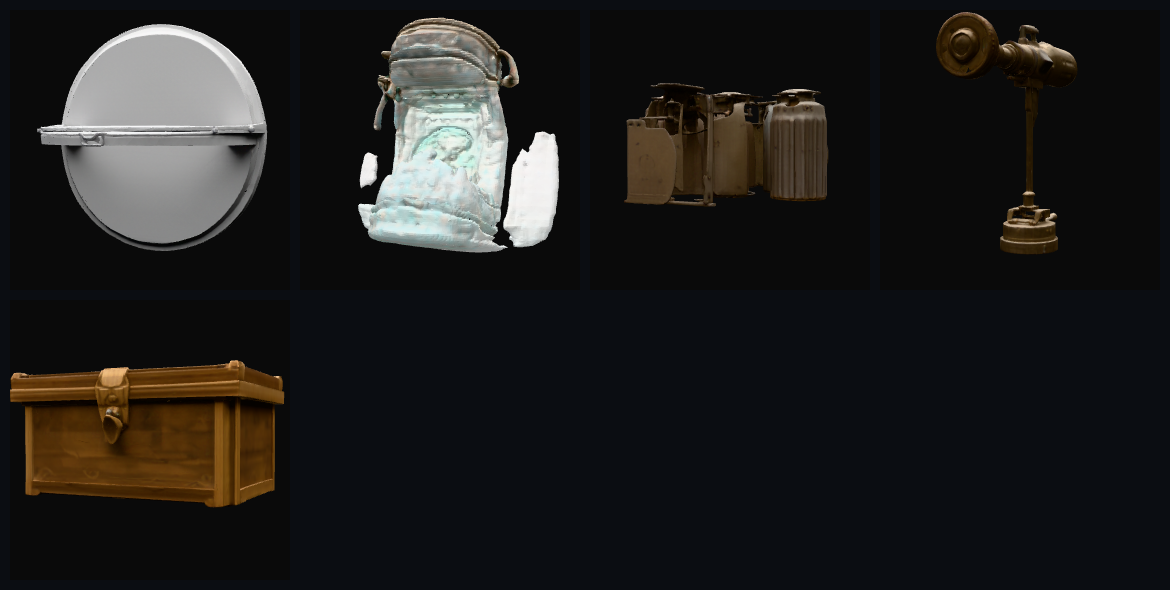

In [ ]:
def build_set(brief: str) -> list:
    """Brief in, QA'd set of real 3D models out."""
    collection = run_art_director(brief)
    print("\nArt director:", collection["reply"], "\n")
    with ThreadPoolExecutor(max_workers=4) as pool:
        inspected = list(pool.map(lambda item: inspect_model(item, brief),
                                  collection["items"]))
    final = repair(inspected, brief)
    passed = sum(1 for item in final if item["verdict"]["passed"])
    print(f"\n{passed}/{len(final)} props pass QA")
    return final


if RUN_LIVE:
    cabin = build_set("Design a collectible set for a deep-sea explorer's cabin.")
    render_models(
        cabin,
        title="A deep-sea explorer's cabin",
        subtitle="Art-directed, built, inspected, and repaired by the model from "
                 "one sentence. Drag to orbit; tap AR on a phone.",
    )
else:
    show_committed("threews_deep_sea_cabin_set.png")


## Error handling and troubleshooting

Every failure path in this notebook is handled where it occurs, so a run
degrades instead of crashing. What that looks like in practice:

| Symptom | Cause | What the notebook does |
|---|---|---|
| `429` on submit or poll | per-IP rate limit on the free lane | honors the `Retry-After` header, then retries; mid-poll it keeps waiting on the **same** job rather than resubmitting it |
| `502` / `503` / `504` on submit | brief GPU-lane saturation | makes up to three submit attempts (two retries) with a pause between them |
| `5xx` or a network blip on a poll | edge hiccup while a job is queued | keeps waiting on the **same** job until the deadline; the job is never resubmitted |
| A job stays `pending` past the timeout | long queue on the free lane | raises `GenerationError`; inside the art-director loop that error is reported back to the model as the tool result instead of crashing the run |
| Other `4xx` on submit | prompt rejected by the lane | not retried; surfaces immediately so you can fix the prompt |
| Render endpoint unavailable | the QA snapshot call failed | QA **fails open**: the prop is kept and marked passed, because a guardrail that can take down the pipeline it guards is worse than no guardrail |
| The vision call fails during QA | transient OpenAI API error, or an unparseable verdict | same fail-open stance: the prop keeps its draft with a "critic unavailable" passed verdict |
| A rebuild fails | the repair generation itself errored | keeps the original draft prop and its original verdict |


## Production checklist

Promoting this pattern from a notebook into a service? Check these first:

| Area | Check |
|---|---|
| Budgets | every loop here is bounded (one art-director conversation, one repair per prop, three submit attempts); keep it that way when you raise the limits |
| Poll cadence | keep honoring `retryAfter` / `Retry-After`; a fleet of impatient pollers is indistinguishable from an attack |
| Caching | `glbUrl` results are immutable; cache them keyed by prompt so repeat briefs and retried jobs cost nothing |
| Concurrency | the free draft lane is per-IP rate-limited; keep `max_workers` modest (four here) or move to a keyed lane |
| Fidelity | the draft lane is single-subject and unrigged by design; three.ws serves higher-poly PBR and rigged lanes with the same tool shape when quality matters |
| Evals | log every structured verdict; the pass rate over time is a free model-graded eval of your whole asset pipeline |


## When to use this pattern

| Use generate / render / inspect / repair when | Skip it when |
|---|---|
| the tool's output is **generative** and can miss silently (3D, images, charts, UI code) | the tool returns deterministic data (a database row, a price); validate with schemas instead |
| quality is judged visually, so only a vision pass can grade it | correctness is checkable in code (types, ranges, invariants) |
| a retry with a better prompt plausibly fixes a failure | failures need a human decision, not a rewrite |
| you can afford one render and one vision call per artifact | you are latency-bound and would rather ship drafts than gate on QA |


## Where to go from here

You now have a model that turns one sentence into a coherent, QA'd set of real
3D assets, and a way to show them off. A few directions:

- **Give it more tools.** The same loop can hold a web-search tool and an image
  tool alongside this one; the model picks per request. 3D just became one more
  capability the model can reach for.
- **Turn the critic into an eval.** The verdicts are already structured data.
  Log them and you have a model-graded eval of your asset pipeline for free:
  track the pass rate over time as you change prompts, models, or generation
  settings.
- **Higher fidelity.** The free draft lane is single-subject and unrigged.
  three.ws also serves higher-poly PBR and rigged-avatar lanes for production
  assets, with the same tool shape and a different endpoint.
- **Wire it into a pipeline.** Every result carries a `glbUrl` (drop into
  Blender, Unity, Unreal, or three.js), a `viewerUrl`, and an `arUrl` for phones.
- **Point another agent at it.** `GET https://three.ws/api/3d` lists the
  endpoints and `GET https://three.ws/api/3d/openapi.json` is a full OpenAPI 3.1
  spec a typed client or tool-loader can import directly.

The pattern generalizes twice over: any capability the model lacks becomes
reachable the moment you wrap its API as a function tool, and any generative
tool becomes trustworthy the moment you render its output where the model can
see it and let it grade its own work.

## References

- [Function calling](https://platform.openai.com/docs/guides/function-calling) - OpenAI guide
- [Images and vision](https://platform.openai.com/docs/guides/images-vision) - OpenAI guide
- [Structured outputs](https://platform.openai.com/docs/guides/structured-outputs) - OpenAI guide
- [Responses API](https://platform.openai.com/docs/api-reference/responses) - API reference
- [`<model-viewer>`](https://modelviewer.dev/) - open web component for rendering glTF/GLB
- [glTF 2.0](https://www.khronos.org/gltf/) - the 3D asset format returned by the API
- [Microsoft TRELLIS](https://github.com/microsoft/TRELLIS) - the open text-to-3D model behind the free lane
- [three.ws 3D API](https://three.ws/api/3d) - endpoint discovery, with a full spec at [`/api/3d/openapi.json`](https://three.ws/api/3d/openapi.json)